In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [2]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("CooperUnion/anime-recommendations-database")

print("Path to dataset files:", path)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/luckyc/.cache/kagglehub/datasets/CooperUnion/anime-recommendations-database/versions/1


In [4]:
#get the anime dataset

anime_data = pd.read_csv("anime.csv")

In [5]:
#get rating dataset
anime_rating = pd.read_csv("rating.csv")

In [6]:
#number of rows and columns in anime dataset
data_shape = anime_data.shape
print(f" The DataFrame has {data_shape[0]} rows and {data_shape[1]} columns! \n")
print(anime_data.info())

 The DataFrame has 12294 rows and 7 columns! 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB
None


In [7]:
#number of rows and colums in rating dataset
rating_shape = anime_rating.shape
print(f" The DataFrame has {rating_shape[0]} rows and {rating_shape[1]} columns! \n")
print(anime_rating.info())

 The DataFrame has 7813737 rows and 3 columns! 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7813737 entries, 0 to 7813736
Data columns (total 3 columns):
 #   Column    Dtype
---  ------    -----
 0   user_id   int64
 1   anime_id  int64
 2   rating    int64
dtypes: int64(3)
memory usage: 178.8 MB
None


In [8]:
#top 5 rows 
anime_data.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [9]:
#last 5 rows
anime_data.tail()

,anime_id,name,genre,type,episodes,rating,members
12289,9316,Toushindai My Lover: Minami tai Mecha-Minami,Hentai,OVA,1,4.15,211
12290,5543,Under World,Hentai,OVA,1,4.28,183
12291,5621,Violence Gekiga David no Hoshi,Hentai,OVA,4,4.88,219
12292,6133,Violence Gekiga Shin David no Hoshi: Inma Dens...,Hentai,OVA,1,4.98,175
12293,26081,Yasuji no Pornorama: Yacchimae!!,Hentai,Movie,1,5.46,142


In [10]:
# checking min of rating column in anime data dataset
anime_data_min = anime_data["rating"].min()
print(f"The minimum in the anime data dataset for the Rating column is {anime_data_min}")


The minimum in the anime data dataset for the Rating column is 1.67


In [11]:
# checking min of rating column in anime data dataset
anime_data_max = anime_data["rating"].max()
print(f"The maximum in the anime data dataset for the Rating column is {anime_data_max}")


The maximum in the anime data dataset for the Rating column is 10.0


In [12]:
#top 5 rows of rating
anime_rating.head()

,user_id,anime_id,rating
0,1,20,-1
1,1,24,-1
2,1,79,-1
3,1,226,-1
4,1,241,-1


In [13]:
#last 5 rows of rating
anime_rating.tail()

,user_id,anime_id,rating
7813732,73515,16512,7
7813733,73515,17187,9
7813734,73515,22145,10
7813735,73516,790,9
7813736,73516,8074,9


In [14]:
# checking min of rating column in anime rating dataset
anime_rating_min = anime_rating["rating"].min()
print(f"The minimum in the anime rating dataset for the Rating column is {anime_rating_min}")


The minimum in the anime rating dataset for the Rating column is -1


In [15]:
#checking max of rating column in anime rating dataset
anime_rating_max = anime_rating["rating"].max()
print(f"The maximum in the anime rating dataset for the Rating column is {anime_rating_max}")

The maximum in the anime rating dataset for the Rating column is 10


In [16]:
# checking if any values are null in data of anime data
print(anime_data.isnull().any().any())

True


In [17]:
# Getting a count of null values in each column
anime_data.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [18]:
#Displays only rows that contain null values

anime_data[anime_data.isna().any(axis=1)]

,anime_id,name,genre,type,episodes,rating,members
2844,33242,IS: Infinite Stratos 2 - Infinite Wedding,NaN,Special,1,7.15,6604
3541,33589,ViVid Strike!,NaN,TV,12,6.96,12345
6040,29765,Metropolis (2009),NaN,Movie,1,6.27,313
6646,32695,Match Shoujo,NaN,ONA,1,6.02,242
7018,33187,Katsudou Shashin,NaN,Movie,1,5.79,607
...,...,...,...,...,...,...,...
12274,34492,Nuki Doki! Tenshi to Akuma no Sakusei Battle -...,Hentai,OVA,Unknown,NaN,392
12279,34491,Sagurare Otome The Animation,Hentai,OVA,1,NaN,79
12280,34312,Saimin Class,Hentai,OVA,Unknown,NaN,240
12282,34388,Shikkoku no Shaga The Animation,Hentai,OVA,Unknown,NaN,195


In [19]:
#Column names for anime data
anime_data.columns

Index(['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members'], dtype='object')

In [20]:
#using describe for anime data
pd.options.display.float_format = "{:,.2f}".format
anime_data.describe()

,anime_id,rating,members
count,"12,294.00","12,064.00","12,294.00"
mean,"14,058.22",6.47,"18,071.34"
std,"11,455.29",1.03,"54,820.68"
min,1.00,1.67,5.00
25%,"3,484.25",5.88,225.00
50%,"10,260.50",6.57,"1,550.00"
75%,"24,794.50",7.18,"9,437.00"
max,"34,527.00",10.00,"1,013,917.00"


In [21]:
# checking if any values are null in data of anime rating
print(anime_rating.isnull().any().any())

False


In [22]:
anime_rating.isnull().any(axis=0)

user_id     False
anime_id    False
rating      False
dtype: bool

In [23]:
#column names for anime rating
anime_rating.columns

Index(['user_id', 'anime_id', 'rating'], dtype='object')

In [24]:
#using describe for anime rating
pd.options.display.float_format = "{:,.2f}".format
anime_rating.describe()

,user_id,anime_id,rating
count,"7,813,737.00","7,813,737.00","7,813,737.00"
mean,"36,727.96","8,909.07",6.14
std,"20,997.95","8,883.95",3.73
min,1.00,1.00,-1.00
25%,"18,974.00","1,240.00",6.00
50%,"36,791.00","6,213.00",7.00
75%,"54,757.00","14,093.00",9.00
max,"73,516.00","34,519.00",10.00


In [25]:
#convert data columns to title case
anime_data.columns = anime_data.columns.str.title()
anime_data.head(2)

,Anime_Id,Name,Genre,Type,Episodes,Rating,Members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665


In [26]:
#convert rating columns to title case
anime_rating.columns = anime_rating.columns.str.title()
anime_rating.head(2)

,User_Id,Anime_Id,Rating
0,1,20,-1
1,1,24,-1


In [27]:
columns_to_drop = ["Episodes", "Members"]

In [28]:
#actually dropping columns and checking first 2 rows

anime_data_drop = anime_data.drop(columns = columns_to_drop)

anime_data_drop.head(2)

,Anime_Id,Name,Genre,Type,Rating
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,9.37
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,9.26


In [29]:
#anime_duplicate_removal = anime_data_drop.drop_duplicates(subset="Name", keep='first')

#df['Name_lower'] = df['Name'].str.lower()  # Create a lower-case version of the 'Name' column for case-insensitive matching
#df_cleaned = df.drop_duplicates(subset='Name_lower', keep='first')  # Drop duplicates based on the 'Name_lower' column

In [30]:
# Removing only the NaN / Null values as they appeared in dataset
anime_data_clean = anime_data_drop.dropna(how= "any")
anime_data_clean

,Anime_Id,Name,Genre,Type,Rating
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,9.37
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,9.26
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,9.25
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,9.17
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,9.16
...,...,...,...,...,...
12289,9316,Toushindai My Lover: Minami tai Mecha-Minami,Hentai,OVA,4.15
12290,5543,Under World,Hentai,OVA,4.28
12291,5621,Violence Gekiga David no Hoshi,Hentai,OVA,4.88
12292,6133,Violence Gekiga Shin David no Hoshi: Inma Dens...,Hentai,OVA,4.98


In [31]:
#displays any nulls that may have not been cleaned. if clean is proper it should be blank

anime_data_clean[anime_data_clean.isna().any(axis=1)]

,Anime_Id,Name,Genre,Type,Rating


In [32]:
anime_data_clean.head()

,Anime_Id,Name,Genre,Type,Rating
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,9.37
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,9.26
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,9.25
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,9.17
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,9.16


In [33]:
anime_data_clean.tail()

,Anime_Id,Name,Genre,Type,Rating
12289,9316,Toushindai My Lover: Minami tai Mecha-Minami,Hentai,OVA,4.15
12290,5543,Under World,Hentai,OVA,4.28
12291,5621,Violence Gekiga David no Hoshi,Hentai,OVA,4.88
12292,6133,Violence Gekiga Shin David no Hoshi: Inma Dens...,Hentai,OVA,4.98
12293,26081,Yasuji no Pornorama: Yacchimae!!,Hentai,Movie,5.46


In [34]:
#QUICK math facts of numerical items
anime_data_clean.describe()

,Anime_Id,Rating
count,"12,017.00","12,017.00"
mean,"13,638.00",6.48
std,"11,231.08",1.02
min,1.00,1.67
25%,"3,391.00",5.89
50%,"9,959.00",6.57
75%,"23,729.00",7.18
max,"34,519.00",10.00


In [35]:
#Checking shape of cleaned dataset
anime_data_clean.shape

(12017, 5)

In [36]:
anime_data_clean.head()

,Anime_Id,Name,Genre,Type,Rating
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,9.37
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,9.26
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,9.25
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,9.17
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,9.16


In [37]:
def filter_by_name(anime_data_clean, search_term):
    # use str.contains() for partial match
    return anime_data_clean[anime_data_clean["Name"].str.contains(search_term, case=False)]

In [38]:
filter_by_name(anime_data_clean, "Stargazer")


,Anime_Id,Name,Genre,Type,Rating
2556,1215,Mobile Suit Gundam Seed C.E.73: Stargazer,"Mecha, Military, Sci-Fi, Space",ONA,7.23


In [39]:
#This is the rating information for the anime_data dataset which has a column for rating

def summarize_anime_data(anime_data_clean: anime_data) -> str:
    """
    Calculates and summarizes the total, mean, and median number of Rating in 
    Anime dataset.

    Parameters:
        anime_data (pandas.DataFrame): The anime dataset containing a 
                                         'Rating' column.

    Returns:
        str: A formatted string summarizing the total, mean (rounded to 2 decimal places),
             and median number of ratings.
    """
    # Calculate total, mean, and median backers
    anime_data_rating_sum = anime_data_clean['Rating'].sum()
    anime_data_rating_mean = anime_data_clean['Rating'].mean().round(2)
    anime_data_rating_median = anime_data_clean['Rating'].median()

    # Return a formatted string
    return (f"The total number of Ratings is {anime_data_rating_sum}\n"
            f"The mean number of Ratings is {anime_data_rating_mean}\n"
            f"The median number of Ratings is {anime_data_rating_median}")


In [40]:
#This is the summary of anime_data rating (sum, mean and median)
summary_anime_data = summarize_anime_data(anime_data_clean)
print(summary_anime_data)

The total number of Ratings is 77849.3
The mean number of Ratings is 6.48
The median number of Ratings is 6.57


In [41]:
#This is the rating information for the anime_rating dataset which also has a rating column
def summarize_anime_rating(anime_rating) -> str:
    """
    Calculates and summarizes the total, mean, and median number of Rating in 
    Anime rating dataset.

    Parameters:
        anime_data (pandas.DataFrame): The anime rating dataset containing a 
                                         'Rating' column.

    Returns:
        str: A formatted string summarizing the total, mean (rounded to 2 decimal places),
             and median number of ratings.
    """
    # Calculate total, mean, and median backers
    anime_rating_sum = anime_rating['Rating'].sum()
    anime_rating_mean = anime_rating['Rating'].mean().round(2)
    anime_rating_median = anime_rating['Rating'].median()

    # Return a formatted string
    return (f"The total number of Ratings is {anime_rating_sum}\n"
            f"The mean number of Ratings is {anime_rating_mean}\n"
            f"The median number of Ratings is {anime_rating_median}")


In [42]:
#This is the summary of anime_rating dataset ratings (sum, mean, median)
#summary_anime_rating = summarize_anime_rating(anime_rating)
#print(summary_anime_rating)

In [43]:
#Attempt to merge dataframes anime_data_clean and anime_rating 
merged_anime = pd.merge(anime_data_clean, anime_rating, on='Anime_Id', how='inner')


In [44]:
merged_anime.shape

(7813611, 7)

In [45]:
#Checking top view
merged_anime.head()

,Anime_Id,Name,Genre,Type,Rating_x,User_Id,Rating_y
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,9.37,99,5
1,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,9.37,152,10
2,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,9.37,244,10
3,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,9.37,271,10
4,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,9.37,278,-1


In [46]:
#Checking bottom view

merged_anime.tail()

,Anime_Id,Name,Genre,Type,Rating_x,User_Id,Rating_y
7813606,6133,Violence Gekiga Shin David no Hoshi: Inma Dens...,Hentai,OVA,4.98,39532,-1
7813607,6133,Violence Gekiga Shin David no Hoshi: Inma Dens...,Hentai,OVA,4.98,48766,-1
7813608,6133,Violence Gekiga Shin David no Hoshi: Inma Dens...,Hentai,OVA,4.98,60365,4
7813609,26081,Yasuji no Pornorama: Yacchimae!!,Hentai,Movie,5.46,27364,-1
7813610,26081,Yasuji no Pornorama: Yacchimae!!,Hentai,Movie,5.46,48766,-1


In [47]:
#Removing Duplicates
merged_anime_clean = merged_anime.drop_duplicates(subset="Anime_Id", keep='first')

In [48]:
#Mean of rating_x and rating_y to creating Rating_mean

merged_anime['Rating_Mean']= merged_anime[['Rating_x', 'Rating_y']].mean(axis=1)

In [49]:
cols_to_drop = ["Rating_x", "Rating_y"]

merged_anime_2 = merged_anime.drop(columns = cols_to_drop)



In [50]:
merged_anime_2.head()

,Anime_Id,Name,Genre,Type,User_Id,Rating_Mean
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,99,7.18
1,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,152,9.68
2,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,244,9.68
3,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,271,9.68
4,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,278,4.18


In [63]:
#Removing Duplicates
merged_anime_clean = merged_anime_2.drop_duplicates(subset="Anime_Id", keep='first')

In [64]:
# Filter the DataFrame for successful projects
filtered_data = merged_anime_clean[merged_anime_clean['Rating_Mean'] >= 7.5]

# Group by Category and State and sum the specified columns
top_anime = filtered_data.groupby(['Anime_Id', 'Name', 'Type'])[[ 'Rating_Mean']].mean().reset_index()

# Sort the entire DataFrame by 'Usd Pledged Real' in descending order
top_anime = top_anime.sort_values(by='Rating_Mean', ascending=False)

top_anime.shape

(1713, 4)

In [65]:


top_25_anime_overall= top_anime.sort_values(by='Rating_Mean', ascending=False).head(25)

top_25_anime_overall


,Anime_Id,Name,Type,Rating_Mean
813,5114,Fullmetal Alchemist: Brotherhood,TV,9.63
215,820,Ginga Eiyuu Densetsu,OVA,9.55
1316,15335,Gintama Movie: Kanketsu-hen - Yorozuya yo Eien...,Movie,9.55
56,199,Sen to Chihiro no Kamikakushi,Movie,9.46
136,457,Mushishi,TV,9.39
67,245,Great Teacher Onizuka,TV,9.38
1213,11665,Natsume Yuujinchou Shi,TV,9.38
1577,28957,Mushishi Zoku Shou: Suzu no Shizuku,Movie,9.38
1214,11741,Fate/Zero 2nd Season,TV,9.37
363,1535,Death Note,TV,9.36


In [66]:
def sorted_columns(top_anime, search_value):
    #Filter based on search_value in "Type" column
    filtered_top_anime = top_anime[top_anime["Type"].str.contains(search_value, case=False)]
    
    # Sort the filtered dataframe by "Rating_y" highest to lowest
    sorted_top_anime = filtered_top_anime.sort_values(by="Rating_Mean", ascending=False)
    
    return sorted_top_anime



In [67]:
top_anime_tv= sorted_columns(top_anime, "TV")

In [68]:
top_anime_tv.head()

,Anime_Id,Name,Type,Rating_Mean
813,5114,Fullmetal Alchemist: Brotherhood,TV,9.63
136,457,Mushishi,TV,9.39
67,245,Great Teacher Onizuka,TV,9.38
1213,11665,Natsume Yuujinchou Shi,TV,9.38
1214,11741,Fate/Zero 2nd Season,TV,9.37


In [69]:
top_anime_movie= sorted_columns(top_anime, "Movie")
top_anime_movie.head()

,Anime_Id,Name,Type,Rating_Mean
1316,15335,Gintama Movie: Kanketsu-hen - Yorozuya yo Eien...,Movie,9.55
56,199,Sen to Chihiro no Kamikakushi,Movie,9.46
1577,28957,Mushishi Zoku Shou: Suzu no Shizuku,Movie,9.38
167,578,Hotaru no Haka,Movie,9.29
1075,9260,Kizumonogatari I: Tekketsu-hen,Movie,9.22


In [70]:
top_anime_ova= sorted_columns(top_anime, "OVA")
top_anime_ova.head()

,Anime_Id,Name,Type,Rating_Mean
215,820,Ginga Eiyuu Densetsu,OVA,9.55
900,6336,Mobile Suit Gundam Unicorn,OVA,9.20
1692,33161,Yahari Ore no Seishun Love Comedy wa Machigatt...,OVA,9.16
1381,17739,Hidamari Sketch: Sae Hiro Sotsugyou-hen,OVA,9.09
606,2952,Final Fantasy VII: Advent Children Complete,OVA,9.09


In [71]:
top_anime_special= sorted_columns(top_anime, "Special")
top_anime_special.head()

,Anime_Id,Name,Type,Rating_Mean
1431,20159,Pokemon: The Origin,Special,8.97
935,6862,K-On!: Live House!,Special,8.94
339,1418,Lupin III: Episode 0 &quot;First Contact&quot;,Special,8.89
255,986,Dragon Ball Z Special 1: Tatta Hitori no Saish...,Special,8.88
350,1478,City Hunter: Goodbye My Sweetheart,Special,8.84


In [72]:
top_anime_music= sorted_columns(top_anime, "Music")
top_anime_music.head()

,Anime_Id,Name,Type,Rating_Mean
197,731,Interstella5555: The 5tory of The 5ecret 5tar ...,Music,9.09
1307,14951,Wonderful Rush,Music,8.70
579,2768,CLAMP in Wonderland 2,Music,8.32
1670,32311,Beautiful World,Music,8.31
1110,9930,Snow Halation,Music,8.30


In [73]:
top_anime_ona= sorted_columns(top_anime, "ONA")
top_anime_ona.head()

,Anime_Id,Name,Type,Rating_Mean
1680,32668,Noblesse: Awakening,ONA,8.86
1289,14123,Pokemon Black and White 2: Introduction Movie,ONA,8.86
1702,33605,Ling Qi,ONA,8.85
1151,10464,Seitokai no Ichizon Lv.2,ONA,8.74
1675,32543,Lu Shidai 2nd Season,ONA,8.65


In [84]:
#Checking values

def summarize_top_anime(top_anime) -> str:
    """
    Calculates and summarizes the total, mean, and median number of Rating in 
    Top Anime dataset.

    Parameters:
        top_anime (pandas.DataFrame): The anime dataset containing a 
                                         'Rating_Mean' column.

    Returns:
        str: A formatted string summarizing the total, mean (rounded to 2 decimal places),
            and median number of ratings.
    """
    # Calculate total, mean, and median backers
    top_anime_sum= top_anime["Rating_Mean"].sum().round(2)
    top_anime_mean = top_anime["Rating_Mean"].mean().round(2)
    top_anime_median = top_anime["Rating_Mean"].median().round(2)

    # Return a formatted string
    return (f"The sum of Rating_Mean is {top_anime_sum}\n"
           f"The mean number of Rating_Mean is {top_anime_mean}\n"
           f"The median number of Rating_Mean is {top_anime_median}")

In [85]:
#This is the summary of top_anime dataset ratings (sum, mean, median)
summary_top_anime = summarize_top_anime(top_anime)
print(summary_top_anime)

The sum of Rating_Mean is 13885.34
The mean number of Rating_Mean is 8.11
The median number of Rating_Mean is 8.04


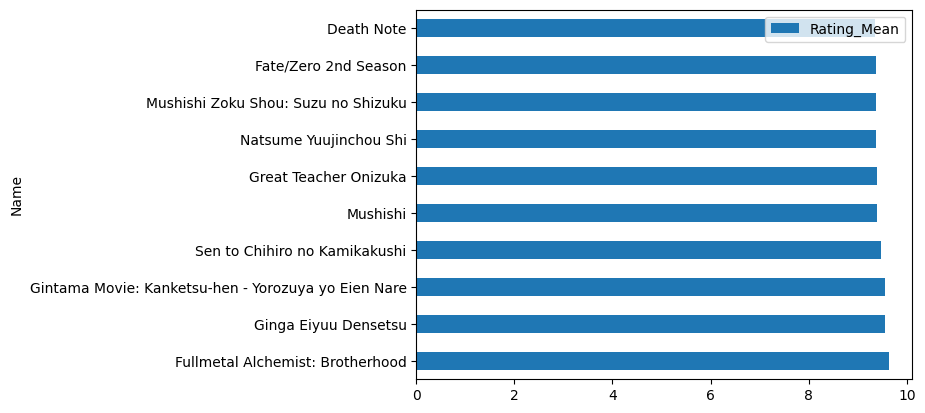

In [ ]:
   #df.plot(x='x', y='y', kind='bar')
  #  plt.show()

overall_top_anime_plot = top_10_anime_overall.plot(x= "Name", y='Rating_Mean', kind="barh")
plt.show()

In [ ]:
#Checking values

#def summarize_merged_anime_x(merged_anime: anime_data_clean) -> str:
    #"""
    #Calculates and summarizes the total, mean, and median number of Rating in 
    #Merged Anime dataset.

    #Parameters:
        #merged_anime (pandas.DataFrame): The anime dataset containing a 
         #                                'Rating' column.

  #  Returns:
   #     str: A formatted string summarizing the total, mean (rounded to 2 decimal places),
    #         and median number of ratings.
   # """
    # Calculate total, mean, and median backers
   # merged_anime_sum_x= merged_anime["Rating_x"].sum().round(2)
    #merged_anime_mean_x = merged_anime["Rating_x"].mean().round(2)
   # merged_anime_median_x = merged_anime["Rating_x"].median()

    # Return a formatted string
    #return (f"The total number of Ratings is {merged_anime_sum_x}\n"
     #       f"The mean number of Ratings is {merged_anime_mean_x}\n"
      #      f"The median number of Ratings is {merged_anime_median_x}")

In [ ]:
#Top 50 for 'TV 'Movie 'OVA' 'Special' 'ONA' 'Music'

sorted_type_ova = sorted_columns(grouped_mean_df, "OVA")

sorted_type_ova.head(5)


,Anime_Id,Name,Type,Rating_y
10378,30939,Shiranpuri,OVA,9.00
739,820,Ginga Eiyuu Densetsu,OVA,8.24
6663,12029,Uchuu Senkan Yamato 2199,OVA,7.61
10702,32088,Osomatsu-kun: Iyami wa Hitori Kaze no Naka,OVA,7.50
24,44,Rurouni Kenshin: Meiji Kenkaku Romantan - Tsui...,OVA,7.34


In [ ]:
#This is the summary of anime_rating dataset ratings (sum, mean, median)
#summary_merged_anime_x = summarize_merged_anime_x(merged_anime)
#print(summary_merged_anime_x)

In [ ]:
#Checking values

#def summarize_merged_anime_y(merged_anime: anime_rating) -> str:
 #   """
  #  Calculates and summarizes the total, mean, and median number of Rating in 
   # Merged Anime dataset.

  #  Parameters:
   #     merged_anime (pandas.DataFrame): The anime dataset containing a 
    #                                     'Rating' column.

  #  Returns:
   #     str: A formatted string summarizing the total, mean (rounded to 2 decimal places),
    #         and median number of ratings.
   # """
    # Calculate total, mean, and median backers
    #merged_anime_sum_y= merged_anime["Rating_y"].sum().round(2)
    #merged_anime_mean_y = merged_anime["Rating_y"].mean().round(2)
    #merged_anime_median_y = merged_anime["Rating_y"].median()

    # Return a formatted string
   # return (f"The total number of Ratings is {merged_anime_sum_y}\n"
    #        f"The mean number of Ratings is {merged_anime_mean_y}\n"
     #       f"The median number of Ratings is {merged_anime_median_y}")

In [ ]:
#This is the summary of anime_rating dataset ratings (sum, mean, median)
#summary_merged_anime_y = summarize_merged_anime_y(merged_anime)
#print(summary_merged_anime_y)